<a href="https://colab.research.google.com/github/franz-hufana/Thesis-MobileNet/blob/main/MobileNetV2-Test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy
import os
import numpy as np
import seaborn as sns
from imageio import imread
from skimage.transform import resize
from sklearn.utils import shuffle
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import decode_predictions
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras import Model
from tensorflow.keras.preprocessing import image
from google.colab import files


In [ ]:
uploaded = files.upload()

Saving wood_data.zip to wood_data.zip


In [ ]:
!unzip wood_data.zip

Archive:  wood_data.zip
   creating: woods/
   creating: woods/cracks/
  inflating: woods/cracks/c(1).png   
  inflating: woods/cracks/c(10).png  
  inflating: woods/cracks/c(100).png  
  inflating: woods/cracks/c(101).png  
  inflating: woods/cracks/c(102).png  
  inflating: woods/cracks/c(103).png  
  inflating: woods/cracks/c(104).png  
  inflating: woods/cracks/c(105).png  
  inflating: woods/cracks/c(106).png  
  inflating: woods/cracks/c(107).png  
  inflating: woods/cracks/c(108).png  
  inflating: woods/cracks/c(109).png  
  inflating: woods/cracks/c(11).png  
  inflating: woods/cracks/c(110).png  
  inflating: woods/cracks/c(111).png  
  inflating: woods/cracks/c(112).png  
  inflating: woods/cracks/c(113).png  
  inflating: woods/cracks/c(114).png  
  inflating: woods/cracks/c(115).png  
  inflating: woods/cracks/c(116).png  
  inflating: woods/cracks/c(117).png  
  inflating: woods/cracks/c(118).png  
  inflating: woods/cracks/c(119).png  
  inflating: woods/cracks/c(12).png

In [ ]:
# MobileNetV2 Model

model = MobileNetV2(weights='imagenet')
model.summary()

14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 3,538,984 (13.50 MB)

 Trainable params: 3,504,872 (13.37 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [ ]:
# Folder Containing the Images

folder_path = '/content/woods'

# Label Mapping

label_map = {
    'c': 0,   # cracks
    'f': 1,   # fuzz
    'k': 2,   # knothole
    'n': 3    # no defect
}

class_names = ['cracks', 'fuzz', 'knothole', 'no defect']

image_paths = []

# Normalizing the Dataset
for root, dirs, files in os.walk(folder_path):
    for file_name in files:
        if file_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            image_paths.append(os.path.join(root, file_name))

image_paths = sorted(image_paths)
num_images = len(image_paths)

data = np.empty((num_images, 224, 224, 3), dtype=np.float32)
labels = np.empty(num_images, dtype=int)

for idx, file_path in enumerate(image_paths):
    file_name = os.path.basename(file_path)
    prefix = file_name[0].lower()

    if prefix not in label_map:
        print(f"Skipping unknown file: {file_name}")
        continue

    labels[idx] = label_map[prefix]

    im = imread(file_path)

    if im.ndim == 2:
        im = np.stack([im] * 3, axis=-1)
    elif im.ndim == 3 and im.shape[-1] == 4:
        im = im[:, :, :3]

    im = resize(im, (224, 224), anti_aliasing=True, preserve_range=True)
    im = im.astype(np.float32)
    im = preprocess_input(im)

    data[idx] = im

print("Data shape:", data.shape)
print("Labels shape:", labels.shape)

for i in range(min(10, num_images)):
    print(os.path.basename(image_paths[i]), "->", class_names[labels[i]])

/tmp/ipykernel_553/3435437521.py:40: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  im = imread(file_path)


Data shape: (1000, 224, 224, 3)
Labels shape: (1000,)
c(1).png -> cracks
c(10).png -> cracks
c(100).png -> cracks
c(101).png -> cracks
c(102).png -> cracks
c(103).png -> cracks
c(104).png -> cracks
c(105).png -> cracks
c(106).png -> cracks
c(107).png -> cracks


In [ ]:
# Data Augmentation layers
"""
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])
"""
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.22),
    layers.RandomZoom(0.22),
    layers.RandomContrast(0.1)
])

model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

In [ ]:
# Freezing Pretrained layers and Adding a New Classifier Head for Woods

model.trainable = False
x = data_augmentation(model.input)
x = model(x)
x = GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
wood_output = Dense(4, activation='softmax')(x)
wood_model = Model(inputs=model.input, outputs=wood_output)
wood_model.summary()

Model: "functional_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_25 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_12 (Sequential)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_14     │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# Compile the Model

wood_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer = 'adam',
    metrics = ['accuracy']
)

Epoch 1/20
25/25 - 8s - 339ms/step - accuracy: 0.6425 - loss: 0.9397 - val_accuracy: 0.8850 - val_loss: 0.3785
Epoch 2/20
25/25 - 2s - 76ms/step - accuracy: 0.8612 - loss: 0.3825 - val_accuracy: 0.8750 - val_loss: 0.3230
Epoch 3/20
25/25 - 2s - 76ms/step - accuracy: 0.9038 - loss: 0.2565 - val_accuracy: 0.8900 - val_loss: 0.2964
Epoch 4/20
25/25 - 2s - 76ms/step - accuracy: 0.9388 - loss: 0.1734 - val_accuracy: 0.9000 - val_loss: 0.2585
Epoch 5/20
25/25 - 2s - 89ms/step - accuracy: 0.9450 - loss: 0.1639 - val_accuracy: 0.9100 - val_loss: 0.2355
Epoch 6/20
25/25 - 2s - 80ms/step - accuracy: 0.9450 - loss: 0.1505 - val_accuracy: 0.9150 - val_loss: 0.2175
Epoch 7/20
25/25 - 2s - 77ms/step - accuracy: 0.9413 - loss: 0.1599 - val_accuracy: 0.9300 - val_loss: 0.2186
Epoch 8/20
25/25 - 2s - 77ms/step - accuracy: 0.9575 - loss: 0.1267 - val_accuracy: 0.9250 - val_loss: 0.2224
Epoch 9/20
25/25 - 2s - 77ms/step - accuracy: 0.9550 - loss: 0.1267 - val_accuracy: 0.9250 - val_loss: 0.2069
Epoch 10/

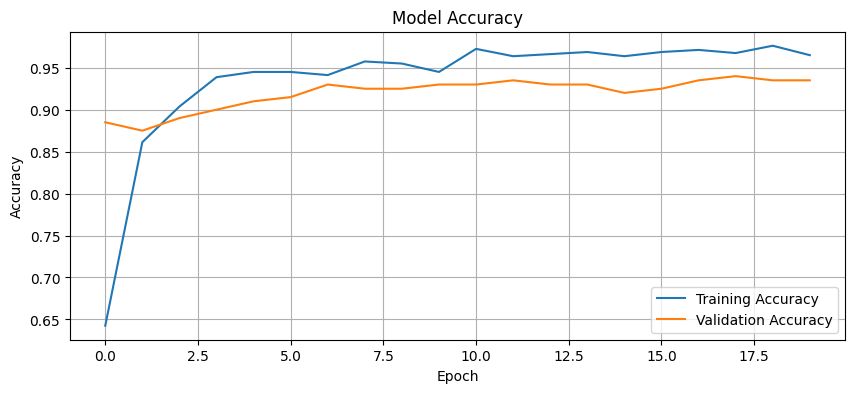

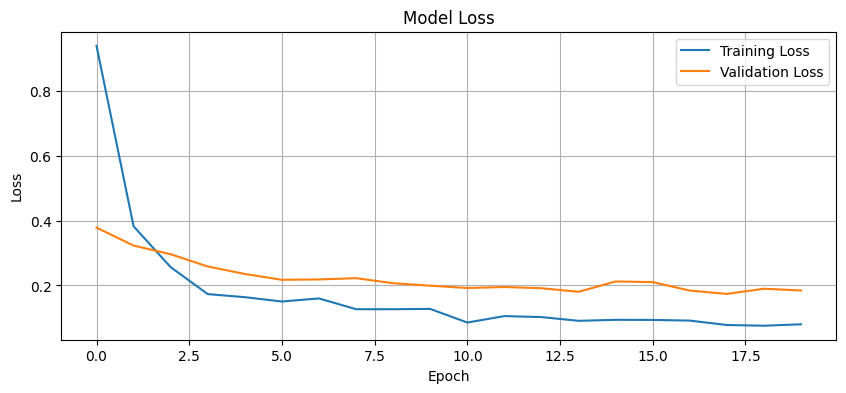

In [ ]:
# Shuffle the dataset then Train

data, labels = shuffle(data, labels, random_state=42)

history = wood_model.fit(
    x=data,
    y=labels,
    batch_size=32,
    epochs=20,
    verbose=2,
    validation_split=0.2
)
# Plot accuracy
plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot loss
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
predictions = wood_model.predict(data)
predictions.shape

32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step


(1000, 4)

In [ ]:
np.argmax(predictions, axis=1)

array([2, 2, 2, 2, 3, 2, 2, 3, 2, 1, 1, 2, 1, 0, 1, 2, 2, 2, 3, 1, 1, 1,
       2, 0, 3, 2, 2, 3, 3, 2, 0, 0, 0, 2, 1, 2, 2, 3, 3, 3, 0, 3, 2, 0,
       2, 1, 2, 0, 2, 1, 1, 2, 1, 2, 1, 2, 0, 2, 1, 0, 0, 2, 2, 3, 0, 3,
       2, 2, 2, 1, 2, 2, 1, 2, 2, 3, 1, 2, 2, 2, 1, 2, 2, 1, 2, 0, 2, 0,
       0, 3, 1, 2, 1, 2, 2, 0, 2, 2, 2, 0, 2, 0, 2, 2, 2, 2, 2, 1, 0, 0,
       2, 3, 3, 0, 1, 2, 0, 2, 1, 2, 2, 2, 1, 2, 2, 1, 1, 2, 3, 1, 0, 2,
       2, 0, 2, 1, 1, 0, 3, 0, 2, 2, 2, 1, 3, 1, 1, 2, 2, 3, 1, 2, 1, 2,
       1, 3, 3, 2, 1, 2, 3, 2, 2, 2, 0, 2, 2, 1, 3, 0, 2, 1, 2, 2, 0, 1,
       0, 1, 2, 3, 2, 0, 2, 2, 1, 0, 1, 2, 2, 2, 2, 0, 3, 3, 3, 2, 0, 0,
       0, 1, 3, 3, 2, 3, 1, 2, 1, 0, 2, 3, 2, 3, 0, 0, 0, 2, 2, 2, 2, 3,
       3, 1, 3, 1, 3, 2, 1, 2, 2, 2, 2, 2, 3, 0, 2, 3, 2, 2, 2, 3, 3, 2,
       3, 2, 2, 0, 1, 1, 2, 1, 1, 2, 3, 2, 2, 0, 2, 3, 1, 2, 2, 3, 2, 2,
       2, 2, 2, 2, 2, 2, 1, 2, 1, 2, 2, 1, 2, 1, 1, 2, 3, 3, 2, 2, 0, 2,
       2, 2, 3, 2, 1, 1, 3, 3, 2, 1, 2, 1, 2, 1, 2,

In [ ]:
# Predict class probabilities
pred_probs = wood_model.predict(data, batch_size=32)
# Convert to class labels
pred_labels = np.argmax(pred_probs, axis=1)

# Calculate F1-score
# 1️⃣ Macro F1: average F1-score across all classes equally
f1_macro = f1_score(labels, pred_labels, average='macro')
print("Macro F1-score:", f1_macro)

# 2️⃣ Micro F1: globally counts total true positives / false positives / false negatives
f1_micro = f1_score(labels, pred_labels, average='micro')
print("Micro F1-score:", f1_micro)

# 3️⃣ Weighted F1: F1-score weighted by number of samples per class
f1_weighted = f1_score(labels, pred_labels, average='weighted')
print("Weighted F1-score:", f1_weighted)

32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step
Macro F1-score: 0.9313655321988656
Micro F1-score: 0.942
Weighted F1-score: 0.9418028128128129


32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step


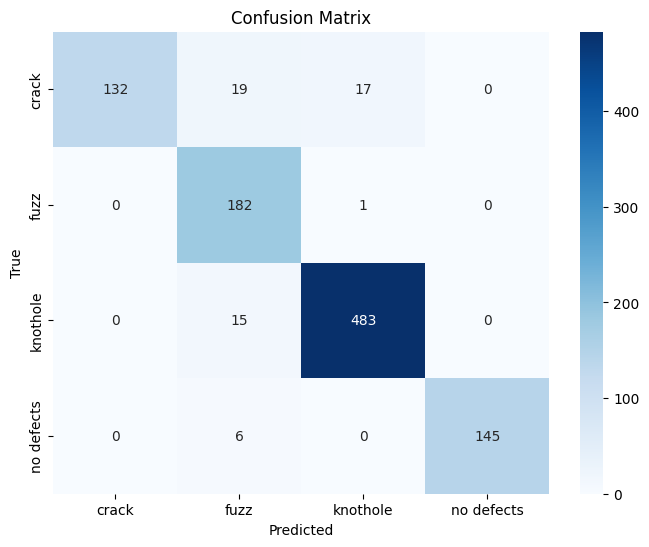

In [ ]:
pred_probs = wood_model.predict(data, batch_size=32)
pred_labels = np.argmax(pred_probs, axis=1)

# Confusion matrix
cm = confusion_matrix(labels, pred_labels)
classes = ['crack', 'fuzz', 'knothole', 'no defects']

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

Saving 001274.jpg to 001274 (3).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Prediction for 001274 (3).jpg: cracks (46.92%)


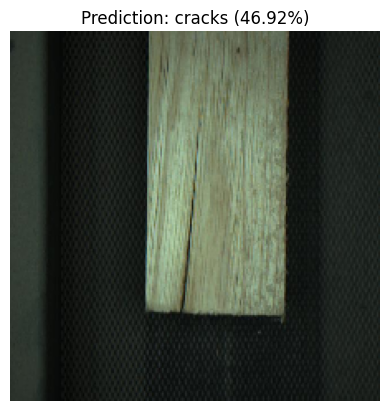

In [ ]:
# Open single image

uploaded = files.upload()
img_path = list(uploaded.keys())[0]
img_height, img_width = 224, 224

img = image.load_img(img_path, target_size=(img_height, img_width))
img_array = image.img_to_array(img) / 255.0
img_array_exp = np.expand_dims(img_array, axis=0)

# Predictions
classes = ['cracks', 'fuzz', 'knothole', 'no_defects']
pred = wood_model.predict(img_array_exp)

class_idx = np.argmax(pred)
confidence = pred[0][class_idx]

print(f"Prediction for {img_path}: {classes[class_idx]} ({confidence*100:.2f}%)")

plt.imshow(img)
plt.axis('off')  # Hide axes
plt.title(f"Prediction: {classes[class_idx]} ({confidence*100:.2f}%)")
plt.show()

In [ ]:
# ----------------------------
# Save trained model
# ----------------------------
wood_model.save("wood_defect_mobilenetv2.h5")

print("Model saved successfully as wood_defect_mobilenetv2.h5")

Model saved successfully as wood_defect_mobilenetv2.h5
